In [1]:
import os
import json
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

In [2]:
JSON_LABELS_PATH = "/kaggle/input/datasets/vladyslavsydorak/toronto/dataset/labels.jsonl"
BASE_DIR = "/kaggle/input/datasets/vladyslavsydorak/toronto"

JSON_LABELS_PATH = "dataset/labels.jsonl"
BASE_DIR = ""

In [3]:
def parse_dataset_metadata(json_path, base_dir):
    """
    Parses the JSON labels and extracts audio durations and text statistics 
    without loading the full audio arrays into memory.
    """
    with open(json_path, 'r', encoding='utf-8') as f:
        data_dict = json.load(f)
        
    records = []
    missing_files = 0
    all_text = ""

    print(f"Found {len(data_dict)} entries in JSON. Processing files...")
    
    for relative_path, transcript in tqdm(data_dict.items()):
        full_path = os.path.join(base_dir, relative_path)
        
        if not os.path.exists(full_path):
            missing_files += 1
            continue
            
        audio_info = sf.info(full_path)
        duration_sec = audio_info.duration
        
        word_count = len(transcript.split())
        char_count = len(transcript)
        
        records.append({
            "path": relative_path,
            "duration_sec": duration_sec,
            "word_count": word_count,
            "char_count": char_count,
            "transcript": transcript
        })
        all_text += transcript.lower()

    df = pd.DataFrame(records)
    return df, missing_files, all_text

In [4]:
df_analysis, missing_count, combined_text = parse_dataset_metadata(
    JSON_LABELS_PATH, 
    BASE_DIR
)

Found 29232 entries in JSON. Processing files...


  0%|          | 0/29232 [00:00<?, ?it/s]

In [5]:
print(f"Processed: {len(df_analysis)} files")
print(f"Missing files: {missing_count}")

Processed: 18303 files
Missing files: 10929


In [6]:
print("Duration Statistics (Seconds)")
print(df_analysis['duration_sec'].describe().round(2))

print("\nTranscript Statistics (Word Count)")
print(df_analysis['word_count'].describe().round(2))

Duration Statistics (Seconds)
count    18303.00
mean         5.96
std          1.25
min          0.14
25%          5.30
50%          6.20
75%          6.88
max         17.28
Name: duration_sec, dtype: float64

Transcript Statistics (Word Count)
count    18303.00
mean        14.04
std          4.64
min          0.00
25%         11.00
50%         14.00
75%         17.00
max         65.00
Name: word_count, dtype: float64


In [7]:
unique_chars = sorted(list(set(combined_text)))
print("Unique Characters in Transcripts")
print("".join(unique_chars))

Unique Characters in Transcripts
 !"#$%'()*+,-./0123456789:;?@`abcdefghijklmnopqrstuvwxyz«»àáéóąćęğłżʼ́̂абвгдежзийклмнопрстуфхцчшщыьэюяёѓєіїќѻґ–—‘’“”„…‰₴№◎。いかこしすとにまィギザチョヴー何戦挑新


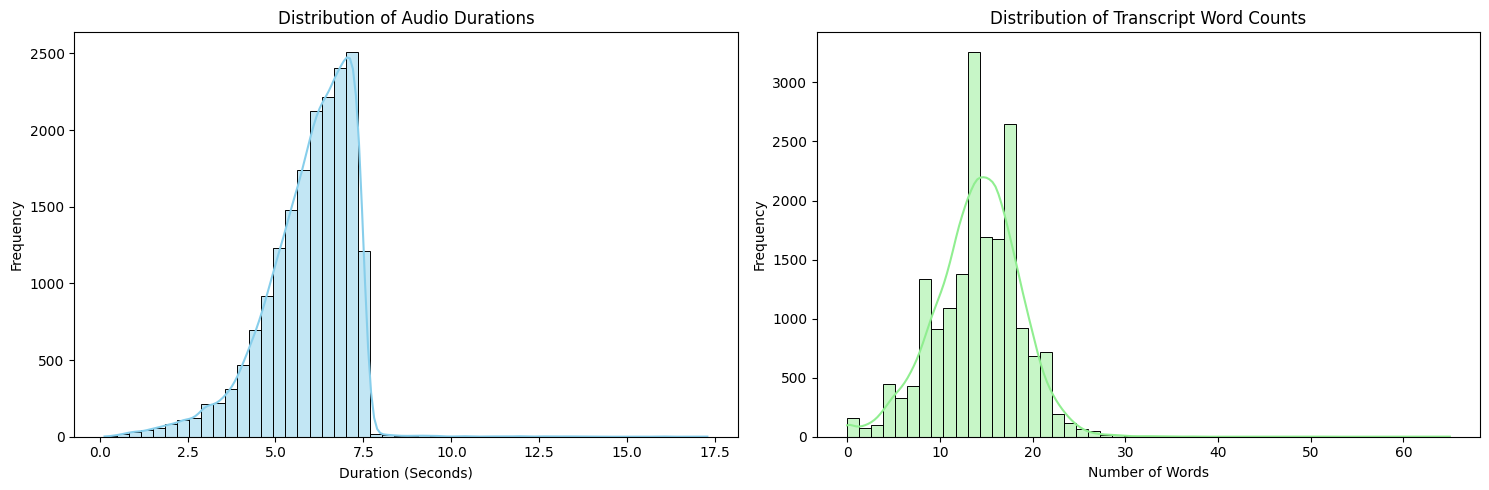

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_analysis['duration_sec'], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Distribution of Audio Durations')
axes[0].set_xlabel('Duration (Seconds)')
axes[0].set_ylabel('Frequency')

sns.histplot(df_analysis['word_count'], bins=50, ax=axes[1], color='lightgreen', kde=True)
axes[1].set_title('Distribution of Transcript Word Counts')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()